# Fase 5 — lendo o resultado

**Cópia de trabalho pessoal, em português.** A versão canônica é
[`01_results.ipynb`](01_results.ipynb), e as duas rodam exatamente o mesmo código — só o texto muda.

**Só o braço corrigido.** Cobre os Steps 9 a 11 do pipeline dela: Manhattan, QQ e as tabelas. O
merge dos cromossomos (Step 9.1 dela) foi puxado para a Fase 4, porque eu precisava dele para
comparar com os resultados dela, e não se repete aqui.

O que a Fase 4 estabeleceu, e que este notebook **mostra** em vez de afirmar:

- nenhum gene atinge significância em nenhuma coorte, em **nenhum** dos dois braços
- a análise está calibrada, então essa ausência é real e não um teste deflacionado
- o ranking por baixo do nulo se mexe bastante, e o gene nº 1 dela é um que nunca testamos

## Preparação

O `bp.hers()` **descarta** linhas em vez de lê-las: 5.391 linhas dela têm as colunas deslocadas,
vindas de três arquivos que perderam a linha de cabeçalho, e um pseudo-gene `-` junta toda variante
que o VEP não soube nomear. Os dois estão documentados nos
[achados da Fase 4](../../phase_4/results/FINDINGS.md). Descartar fazendo barulho é o ponto —
misturar em silêncio foi o que os produziu.

In [1]:
import sys
sys.path.insert(0, "../scripts")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import burden_plots as bp

bp.style()
ours = bp.burden()
theirs = bp.hers()

print(f"ours   {len(ours):>9,} tests   {ours.Region.nunique():>6,} genes")
print(f"theirs {len(theirs):>9,} tests   {theirs.Region.nunique():>6,} genes"
      f"   ({theirs.attrs['rows_dropped']:,} rows dropped, see below)")

ours     472,453 tests   17,943 genes
theirs 1,620,039 tests   19,042 genes   (6,795 rows dropped, see below)


## 1. O resumo

Os dois limiares são os dois denominadores defensáveis: um teste por combinação de máscara × MAF, ou
um por gene. A Fase 4 examinou um terceiro, que colapsa os cortes de MAF que dão p idêntico, e ele
não muda nenhuma resposta.

In [2]:
summary = pd.read_csv("../results/summary.tsv", sep="\t")
summary[["cohort", "genes", "min_pvalue", "bar_per_test", "bar_per_gene",
         "any_significant", "her_min_pvalue", "her_any_significant"]]

,cohort,genes,min_pvalue,bar_per_test,bar_per_gene,any_significant,her_min_pvalue,her_any_significant
0,combined,17943,0.000004,3.125781e-07,0.000003,False,0.000003,False
1,EUR,17928,0.000015,3.140763e-07,0.000003,False,0.000009,False
2,AFR,17789,0.000007,3.261664e-07,0.000003,False,0.000005,False


## 2. Manhattan

Uma figura por coorte, nove painéis: três máscaras na vertical, três cortes de MAF na horizontal. A
linha vermelha é `0,05 / genes`, o limiar mais permissivo que alguém defenderia. Nada cruza em
nenhum painel.

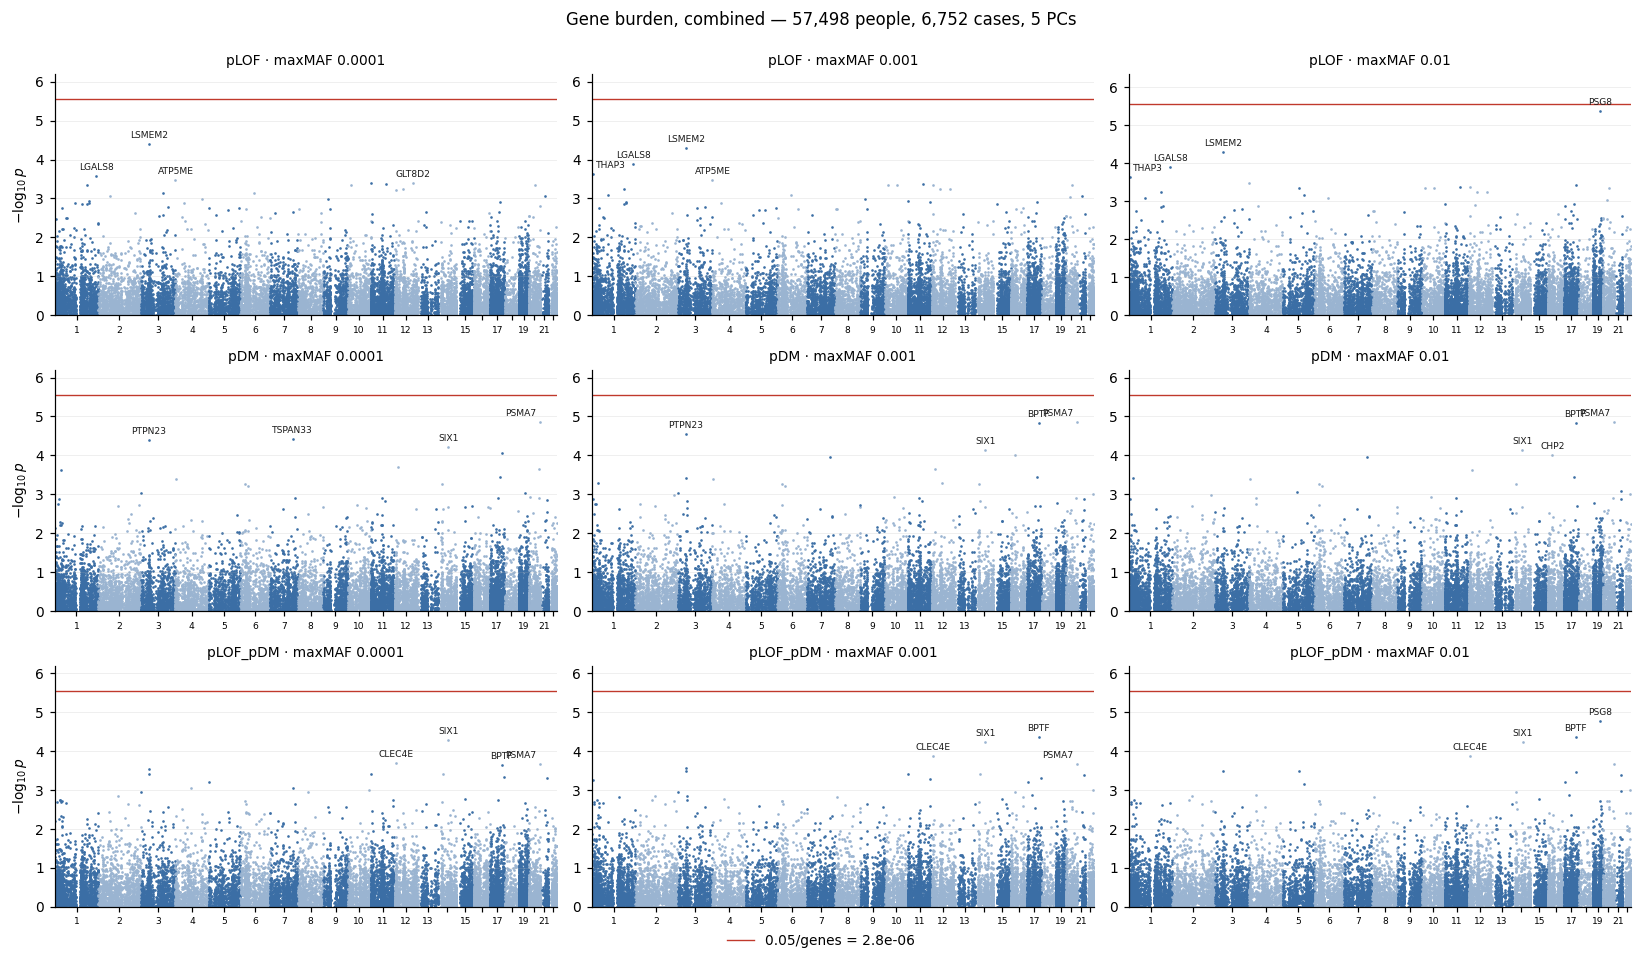

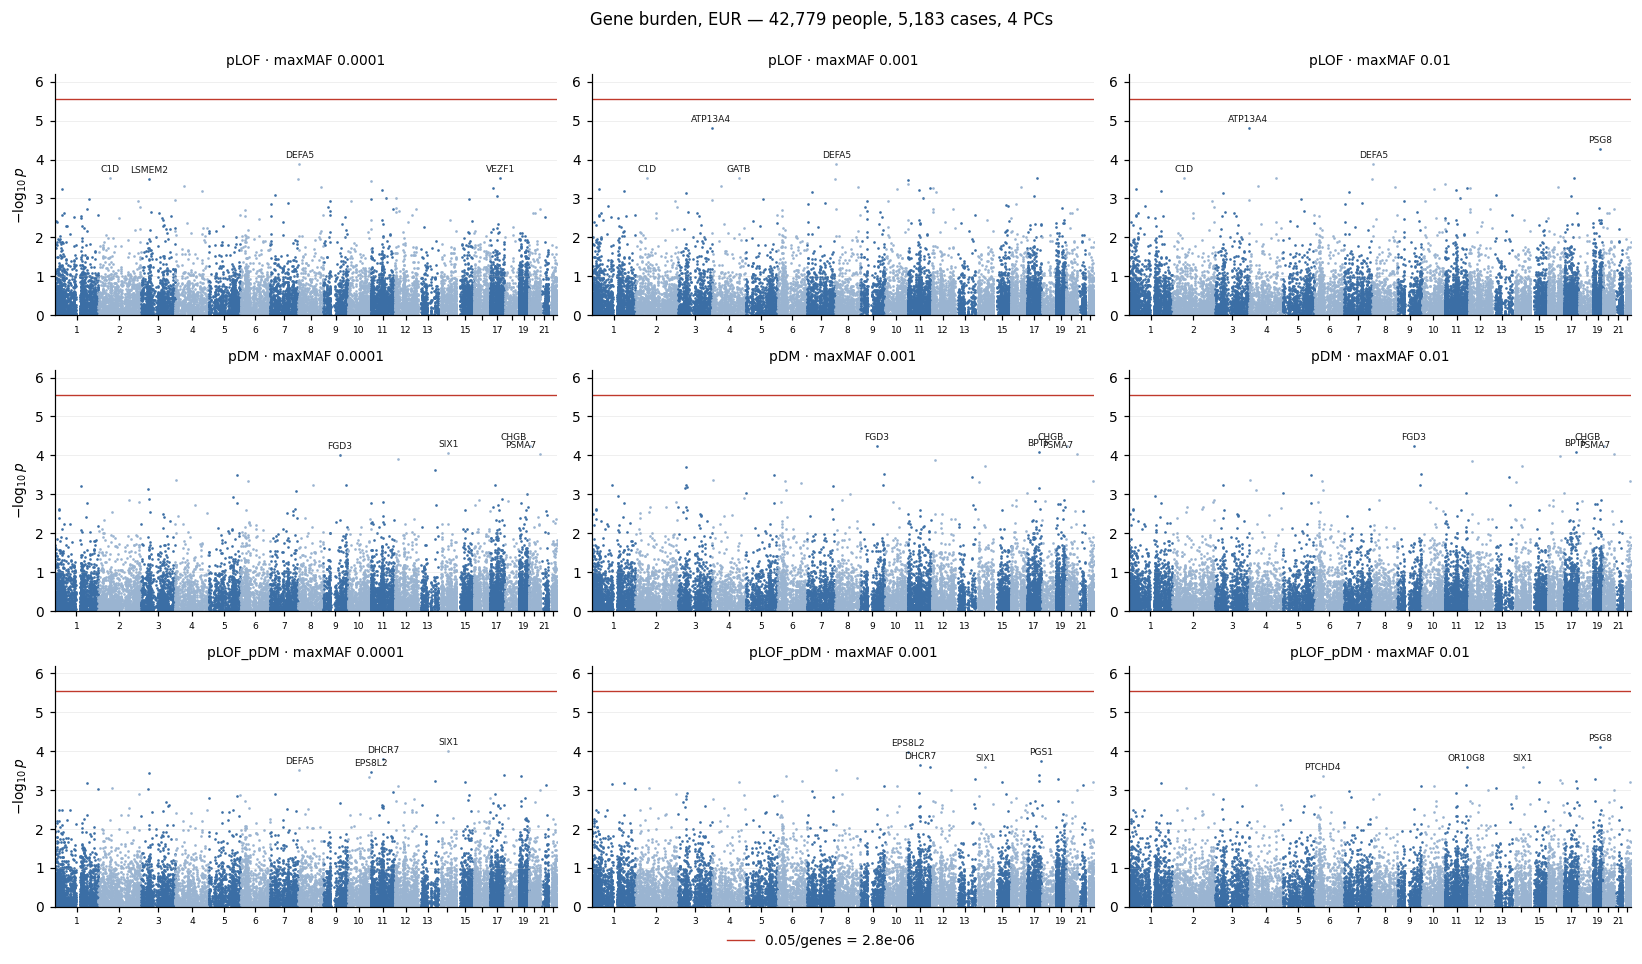

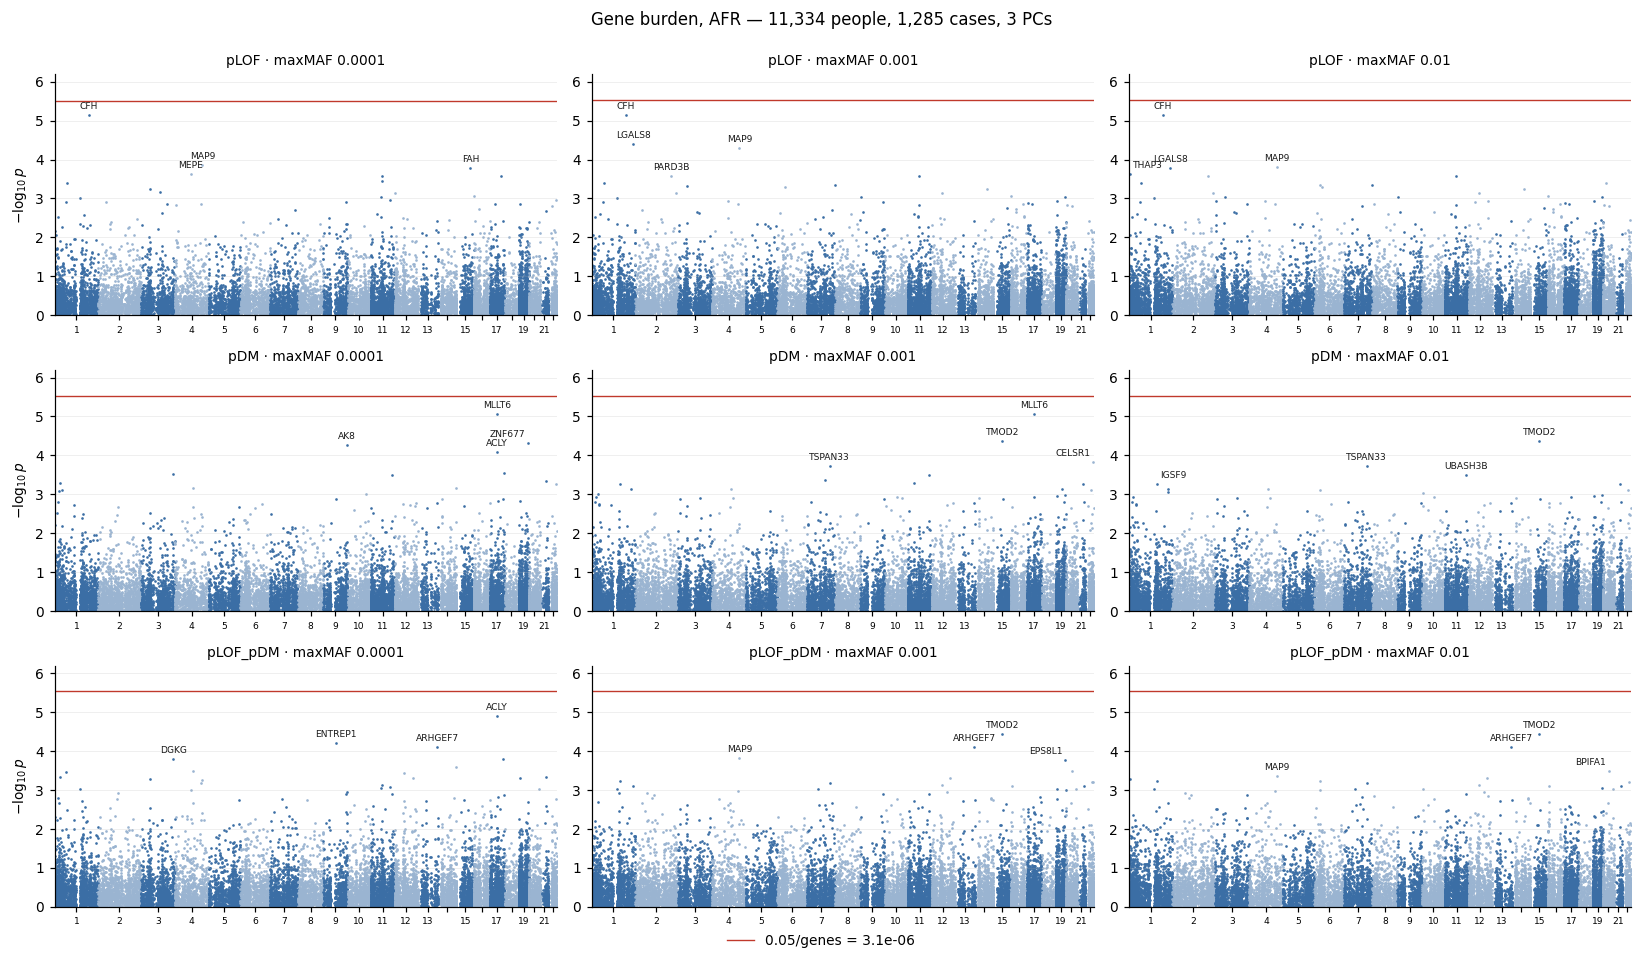

In [3]:
for cohort in bp.COHORTS:
    fig, axes = plt.subplots(3, 3, figsize=(15, 8.5))
    for i, mask in enumerate(bp.MASKS):
        for j, maf in enumerate(bp.MAFS):
            bp.manhattan(ours, cohort, ax=axes[i, j], mask=mask, maf=maf, label_top=4)
            axes[i, j].set_title(f"{mask} · maxMAF {maf}", fontsize=9)
            if i < 2:
                axes[i, j].set_xlabel("")
            if j > 0:
                axes[i, j].set_ylabel("")
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"Gene burden, {cohort} — {bp.N[cohort]:,} people, "
                 f"{bp.CASES[cohort]:,} cases, {bp.PCS[cohort]} PCs", y=0.995)
    fig.tight_layout()
    fig.savefig(f"../figures/manhattan_{cohort}.png")
    plt.show()

## 3. QQ, e se o nulo é real

"Nada passou a barra" e "não tem nada aí" são afirmações diferentes, e um teste conservador produz a
primeira sem sustentar a segunda. O QQ é como se distingue uma da outra.

O λ usa o `qchisq(0.5, 1)` exato = 0,4549364, não o 0,456 do `step10_1_QQplot.R` dela, que infla o λ
em 0,23%. Não muda conclusão nenhuma, e acertar é de graça.

O λ sobre um p-valor de SKAT-O precisa de uma palavra de defesa, já que o λ foi feito para teste de
variante única, onde a estatística nula é qui-quadrado com 1 grau de liberdade, e a do SKAT-O não é.
Ainda assim funciona, porque o que está sendo testado é se os p-valores são **uniformes**: se forem,
a mediana de `qchisq(1-p, 1)` é `qchisq(0.5, 1)`, seja lá o que os produziu.

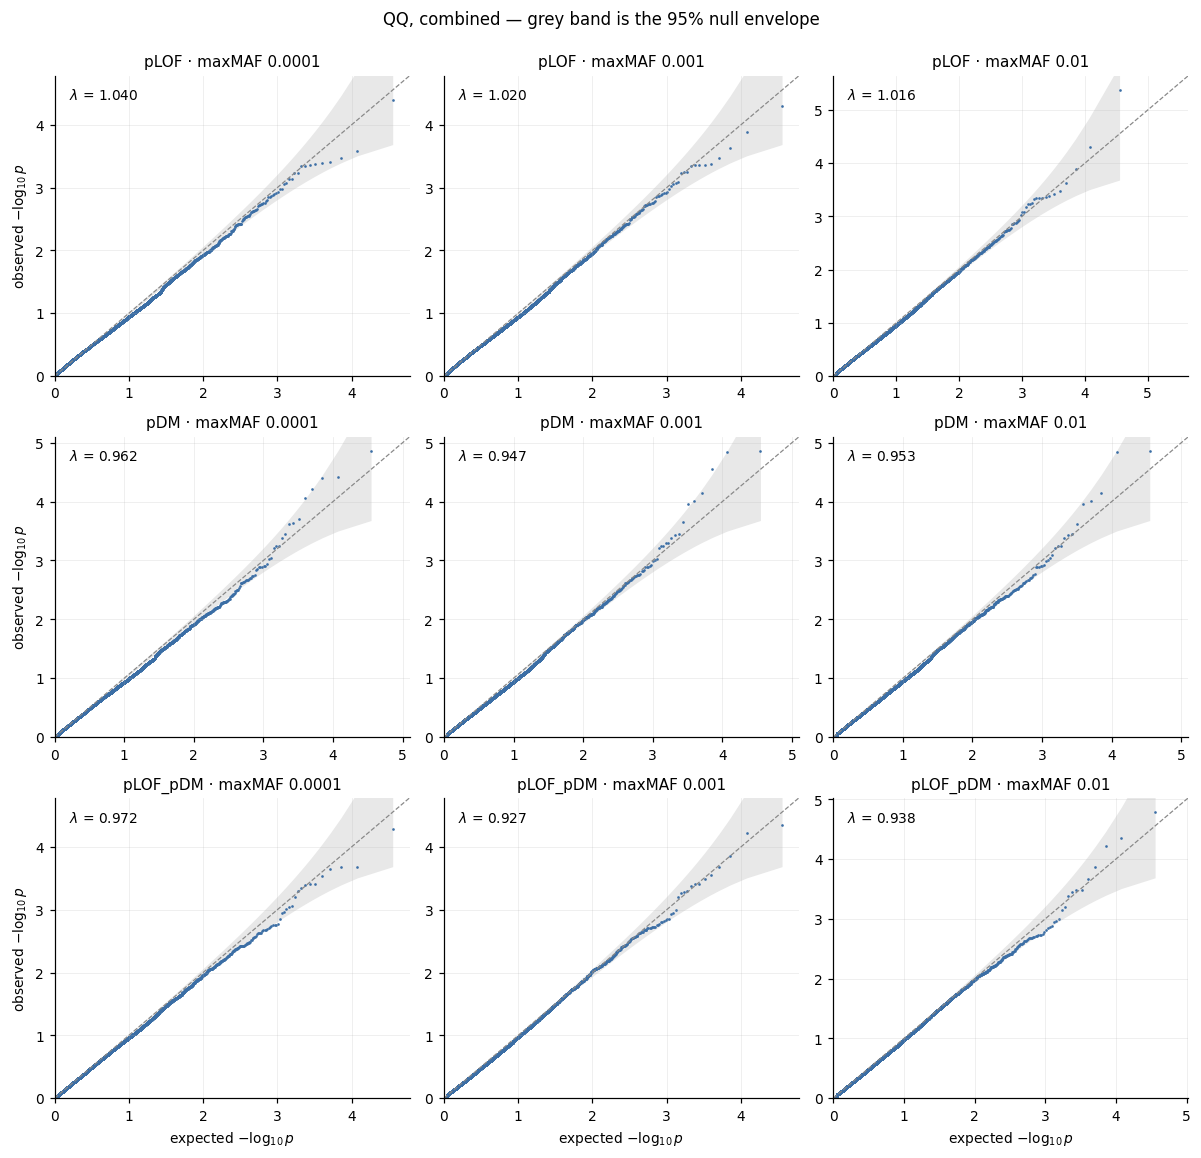

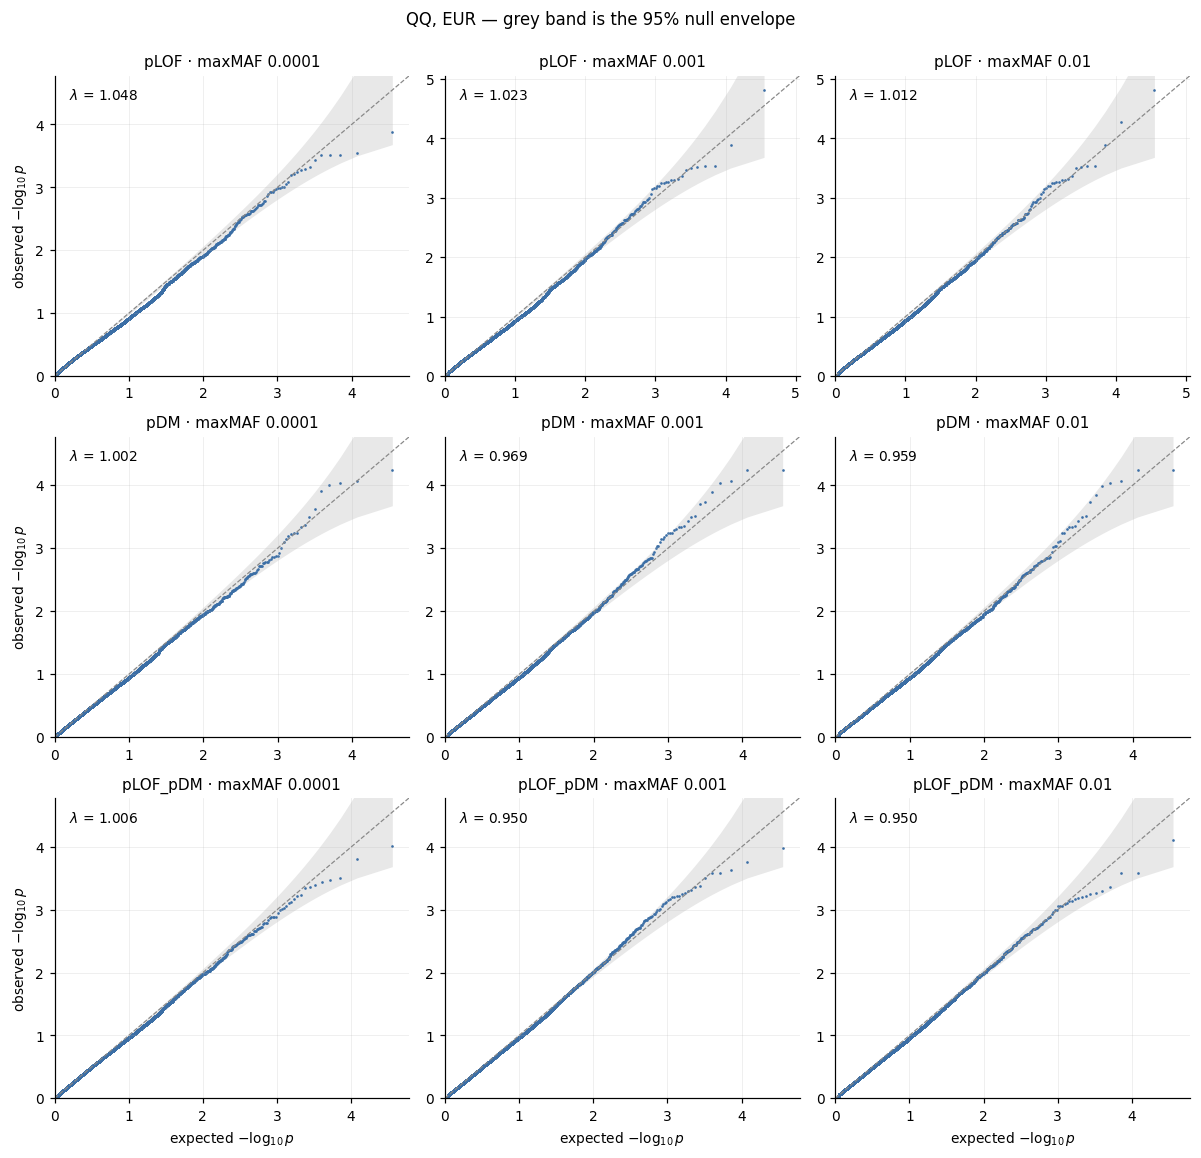

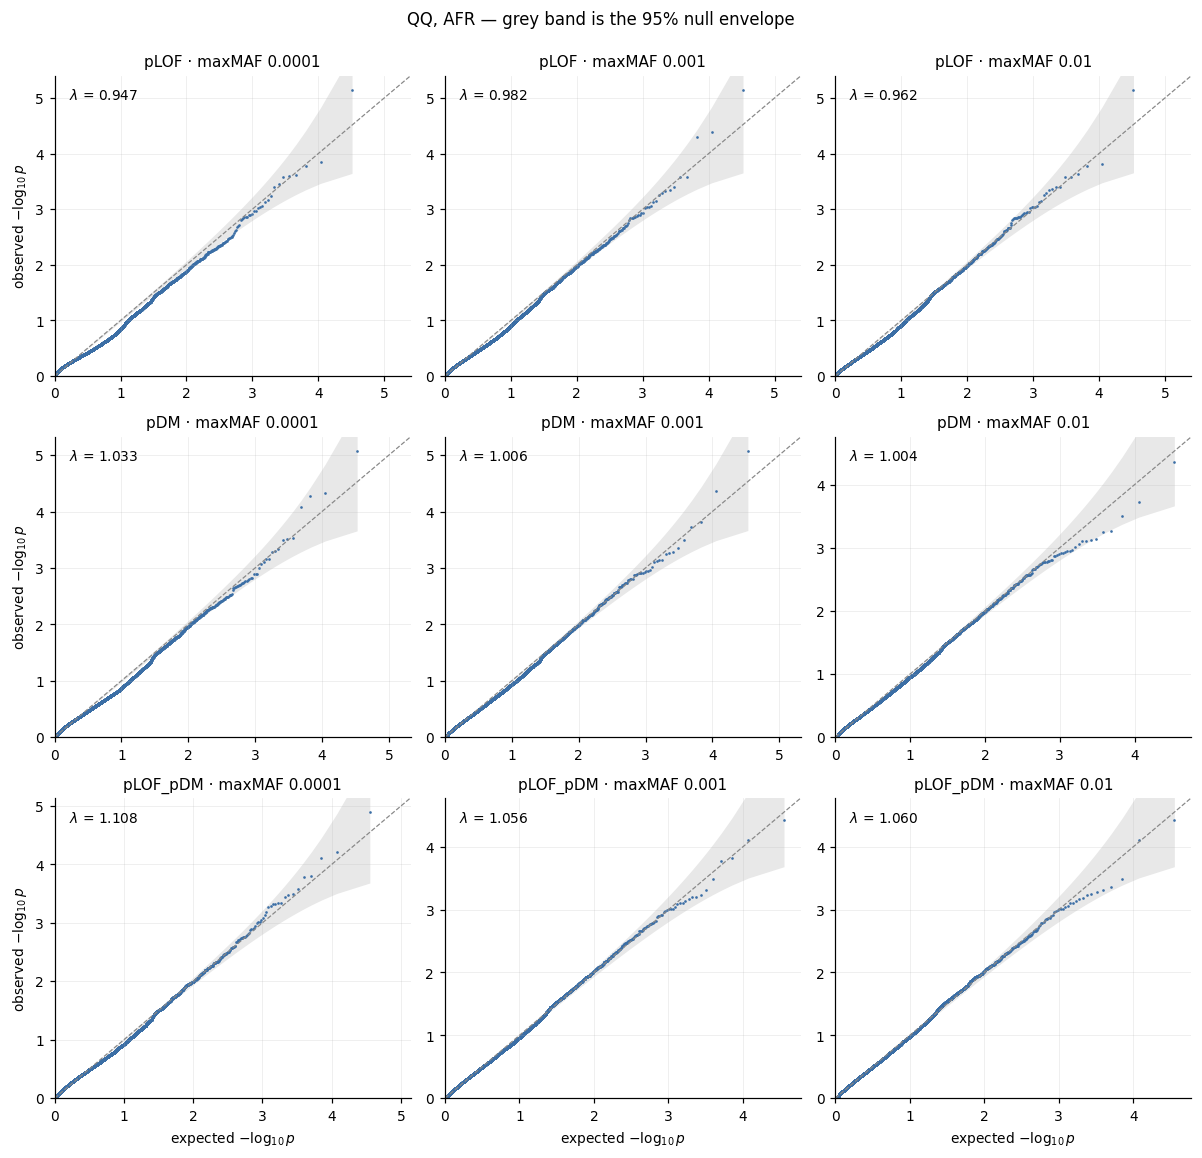

In [4]:
for cohort in bp.COHORTS:
    fig, axes = plt.subplots(3, 3, figsize=(11, 10.5))
    for i, mask in enumerate(bp.MASKS):
        for j, maf in enumerate(bp.MAFS):
            s = ours[(ours.Cohort == cohort) & (ours.Mask == mask) & (ours.max_MAF == maf)]
            bp.qq(s.Pvalue, ax=axes[i, j], title=f"{mask} · maxMAF {maf}")
            if i < 2:
                axes[i, j].set_xlabel("")
            if j > 0:
                axes[i, j].set_ylabel("")
    fig.suptitle(f"QQ, {cohort} — grey band is the 95% null envelope", y=0.997)
    fig.tight_layout()
    fig.savefig(f"../figures/qq_{cohort}.png")
    plt.show()

### O λ numa tabela

Abaixo de 1 é conservador, acima é inflado. Qualquer coisa longe de 1 tornaria os p-valores
inutilizáveis, e nada aqui está longe de 1.

In [5]:
lam = (ours.groupby(["Cohort", "Mask", "max_MAF"])
            .Pvalue.apply(bp.lam)
            .unstack("max_MAF")
            .round(3))
lam.loc[bp.COHORTS]

max_MAF            0.0001  0.0010  0.0100
Cohort   Mask                            
combined pDM        0.962   0.947   0.953
         pLOF       1.040   1.020   1.016
         pLOF_pDM   0.972   0.927   0.938
EUR      pDM        1.002   0.969   0.959
         pLOF       1.048   1.023   1.012
         pLOF_pDM   1.006   0.950   0.950
AFR      pDM        1.033   1.006   1.004
         pLOF       0.947   0.982   0.962
         pLOF_pDM   1.108   1.056   1.060

## 4. Nós contra ela

Esta é a figura pela qual a replicação existe. Um ponto por gene, o melhor p da grade, o valor dela
no eixo x e o nosso no y. Pontos na diagonal são genes que as correções deixaram em paz.

A faixa vermelha embaixo são os genes que ela testou e que nossa reconstrução da Fase 2 removeu por
não serem codificantes de proteína. Eles não têm valor em y porque nunca os testamos, e deixá-los
fora da figura esconderia a diferença mais consequente entre os dois braços — **a marca mais à
direita no painel combined é o `TMC3-AS1`, o gene nº 1 dos resultados dela, um lncRNA cujo resultado
inteiro repousa em duas variantes.**

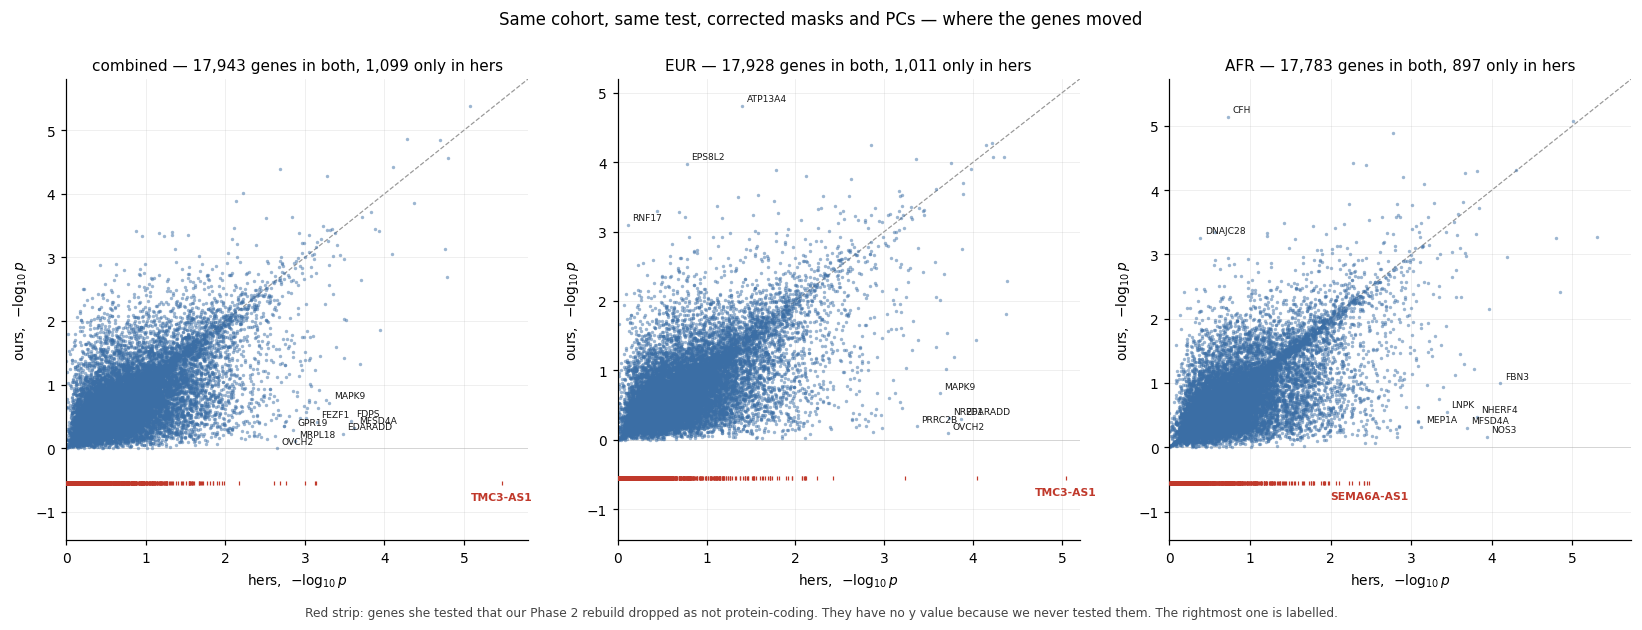

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, cohort in zip(axes, bp.COHORTS):
    bp.comparison(ours, theirs, cohort, ax=ax)
fig.suptitle("Same cohort, same test, corrected masks and PCs — where the genes moved", y=1.0)
fig.text(0.5, -0.02,
         "Red strip: genes she tested that our Phase 2 rebuild dropped as not protein-coding. "
         "They have no y value because we never tested them. The rightmost one is labelled.",
         ha="center", fontsize=8, color="#444444")
fig.tight_layout()
fig.savefig("../figures/comparison_ours_vs_hers.png")
plt.show()

### Quanto de cada lista de top-50 é compartilhado

In [7]:
for cohort in bp.COHORTS:
    o = ours[ours.Cohort == cohort].groupby("Region").Pvalue.min().nsmallest(50)
    t = theirs[theirs.Cohort == cohort].groupby("Region").Pvalue.min().nsmallest(50)
    shared = set(o.index) & set(t.index)
    print(f"{cohort:9s} {len(shared):>2}/50 shared   "
          f"{sorted(shared)[:6]} ...")

combined  24/50 shared   ['AVIL', 'BPTF', 'C17orf58', 'C17orf67', 'CHL1', 'CIMIP1'] ...


EUR       17/50 shared   ['BPTF', 'C1D', 'CFAP157', 'CHGB', 'ESRP2', 'FAM83A'] ...


AFR       15/50 shared   ['AK8', 'CELSR1', 'DGKG', 'ECEL1', 'IGSF9', 'MAP9'] ...


## 5. As tabelas

O `top_hits` traz uma marca `fragile`, porque p-valor sozinho coloca um gene de cinco alelos ao lado
de um de quatrocentos. Um teste é marcado quando o componente de burden discorda do p combinado — o
sinal é todo SKAT, sem direção consistente —, ou quando o gene inteiro colapsou numa unidade só, ou
quando o MAC está abaixo de 20.

Leia a fração marcada antes de ler os genes: no AFR, **26 dos 30 primeiros** estão marcados. Isso é
o tamanho da coorte aparecendo, não uma lista de candidatos.

In [8]:
for cohort in bp.COHORTS:
    t = pd.read_csv(f"../results/top_hits_{cohort}.tsv", sep="\t")
    print(f"=== {cohort}: {int(t.fragile.sum())} of {len(t)} flagged fragile")
    display(t.head(8)[["rank", "Region", "Mask", "max_MAF", "Pvalue",
                       "Pvalue_Burden", "MAC", "MAC_case", "fragile", "why_fragile"]])

=== combined: 16 of 30 flagged fragile


,rank,Region,Mask,max_MAF,Pvalue,Pvalue_Burden,MAC,MAC_case,fragile,why_fragile
0,1,PSG8,pLOF,0.0100,0.000004,0.400967,366,52,True,burden disagrees
1,2,PSMA7,pDM,0.0001,0.000014,0.000014,34,14,True,collapsed to one unit
2,3,BPTF,pDM,0.0010,0.000014,0.000054,334,67,False,-
3,4,PTPN23,pDM,0.0010,0.000027,0.000060,271,53,False,-
4,5,TSPAN33,pDM,0.0001,0.000038,0.000038,30,11,True,collapsed to one unit
5,6,LSMEM2,pLOF,0.0001,0.000041,0.000041,36,13,True,collapsed to one unit
6,7,SIX1,pLOF_pDM,0.0001,0.000052,0.000052,68,18,True,collapsed to one unit
7,8,CHP2,pDM,0.0010,0.000096,0.000058,150,29,False,-


=== EUR: 18 of 30 flagged fragile


,rank,Region,Mask,max_MAF,Pvalue,Pvalue_Burden,MAC,MAC_case,fragile,why_fragile
0,1,ATP13A4,pLOF,0.0010,0.000015,0.000090,112,25,False,-
1,2,PSG8,pLOF,0.0100,0.000053,0.015871,201,42,True,burden disagrees
2,3,FGD3,pDM,0.0010,0.000057,0.174981,118,17,True,burden disagrees
3,4,CHGB,pDM,0.0001,0.000057,0.000057,11,7,True,"collapsed to one unit, MAC=11"
4,5,BPTF,pDM,0.0010,0.000084,0.000190,278,59,False,-
5,6,SIX1,pDM,0.0001,0.000085,0.000085,33,11,True,collapsed to one unit
6,7,PSMA7,pDM,0.0001,0.000091,0.000091,20,9,True,collapsed to one unit
7,8,ESRP2,pDM,0.0100,0.000103,0.000222,223,45,False,-


=== AFR: 26 of 30 flagged fragile


,rank,Region,Mask,max_MAF,Pvalue,Pvalue_Burden,MAC,MAC_case,fragile,why_fragile
0,1,CFH,pLOF,0.0001,0.000007,0.000007,5,5,True,"collapsed to one unit, MAC=5"
1,2,MLLT6,pDM,0.0001,0.000008,0.000008,6,5,True,"collapsed to one unit, MAC=6"
2,3,ACLY,pLOF_pDM,0.0001,0.000013,0.000013,44,15,True,collapsed to one unit
3,4,TMOD2,pLOF_pDM,0.0010,0.000037,0.000037,29,12,True,collapsed to one unit
4,5,LGALS8,pLOF,0.0010,0.000040,0.006266,53,13,True,burden disagrees
5,6,ZNF677,pDM,0.0001,0.000048,0.000048,13,7,True,"collapsed to one unit, MAC=13"
6,7,MAP9,pLOF,0.0010,0.000050,0.071956,58,11,True,burden disagrees
7,8,AK8,pDM,0.0001,0.000053,0.000053,21,9,True,collapsed to one unit


### Os genes que saíram do topo

Os genes mais bem colocados dela que nunca testamos, com o biotipo que os removeu.

In [9]:
dropped = pd.read_csv("../results/dropped_from_top.tsv", sep="\t")
dropped.groupby("Cohort").head(5)[["Cohort", "Region", "her_pvalue", "her_rank", "biotype"]]

,Cohort,Region,her_pvalue,her_rank,biotype
0,combined,TMC3-AS1,0.000003,1,lncRNA
1,combined,NUP153-AS1,0.000723,48,lncRNA
2,combined,TRGV9,0.000747,52,TR_V_gene
3,combined,AGAP13P,0.001006,75,transcribed_unprocessed_pseudogene
4,combined,PRSS46P,0.001740,129,lncRNA
25,EUR,TMC3-AS1,0.000009,1,lncRNA
26,EUR,SLCO1B7,0.000091,8,transcribed_unprocessed_pseudogene
27,EUR,TRGV9,0.000579,47,TR_V_gene
28,EUR,NUP153-AS1,0.003773,268,lncRNA
29,EUR,RUFY1-AS1,0.005667,384,lncRNA


## O que esta fase conclui

1. **Nenhum achado.** Nada é significativo em nenhum dos dois braços, sob nenhum limiar.
2. **A ausência é real.** O λ fica entre 0,95 e 1,11 nos 27 painéis, e os pontos do QQ ficam dentro
   do envelope nulo. O teste está calibrado, levemente conservador, e simplesmente não tem nada a
   reportar.
3. **As correções ainda importaram.** Entre 15 e 24 de cada lista de top-50 muda, e o gene nº 1 dela
   é um lncRNA que nunca testamos. Numa coorte maior, ou em qualquer estudo que escolha genes para
   investigar a partir de uma tabela dessas, essa diferença decide o que é olhado.

Um resultado negativo com um achado metodológico dentro — o que é diferente de, e mais útil que, um
estudo que não acha nada e não aprende nada.